## V1 - Auto Encoder

### Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r "/content/drive/MyDrive/24135120_Shiva Saitej Sharma T/HiRise/dataset_split" /content/dataset_split

TRAIN_NORMAL_DIR = "/content/dataset_split/train/normal"
TEST_NORMAL_DIR = "/content/dataset_split/test/normal"
TEST_ANOMALY_DIR = "/content/dataset_split/test/anomaly_real"

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim #to load optimisations like SGD, Adam, etc. to better optimise weights
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
print(os.listdir('dataset_split/dataset_split'))

['train', 'test']


### Preprocessing Data

In [4]:
transform=transforms.ToTensor()
train_dataset=datasets.ImageFolder(root='dataset_split/dataset_split/train',transform=transform)
data_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=64,shuffle=True)
dataiter=iter(data_loader)
images,labels=next(dataiter)
print(images.shape)

torch.Size([64, 3, 227, 227])


In [6]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train_dataset=datasets.ImageFolder(root='dataset_split/dataset_split/train',transform=transform)
data_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=64,shuffle=True)
images,labels=next(iter(data_loader))
print(images.shape)

torch.Size([64, 3, 224, 224])


In [9]:
print(os.listdir('dataset_split/dataset_split/train'))

['normal']


### Auto Encoder Model

In [7]:
class ConvAutoencoder(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder=nn.Sequential(
        nn.Conv2d(3,16,kernel_size=3,padding=1), # because of the padding
        #the feature map is still 224*224 after convolving with kernel
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(16,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.decoder=nn.Sequential(
        nn.ConvTranspose2d(64,32,kernel_size=2,stride=2),
        nn.ReLU(),

        nn.ConvTranspose2d(32,16,kernel_size=2,stride=2),
        nn.ReLU(),

        nn.ConvTranspose2d(16,3,kernel_size=2,stride=2),
        nn.Sigmoid()
    )
  def forward(self,x):
      encoded=self.encoder(x)
      decoded=self.decoder(encoded)
      return decoded


In [10]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:{device}")
model=ConvAutoencoder().to(device)
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-5)

Using device:cuda


### Training

In [11]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
num_epochs=10
outputs=[]
for epoch in range(num_epochs):
  for i,(img,_) in enumerate(data_loader):
    img=img.to(device)
    recon=model(img)
    loss=criterion(recon,img)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 20 == 0:
        print(f'  epoch {epoch+1} batch {i}/{len(data_loader)} loss={loss.item():.4f}')
  print(f'Epoch:{epoch+1}/{num_epochs},Loss:{loss.item():.4f}')
  outputs.append((epoch,img.cpu(),recon.cpu()))

Using device: cuda
  epoch 1 batch 0/314 loss=0.0273
  epoch 1 batch 20/314 loss=0.0309
  epoch 1 batch 40/314 loss=0.0276
  epoch 1 batch 60/314 loss=0.0175
  epoch 1 batch 80/314 loss=0.0110
  epoch 1 batch 100/314 loss=0.0084
  epoch 1 batch 120/314 loss=0.0035
  epoch 1 batch 140/314 loss=0.0024
  epoch 1 batch 160/314 loss=0.0019
  epoch 1 batch 180/314 loss=0.0017
  epoch 1 batch 200/314 loss=0.0018
  epoch 1 batch 220/314 loss=0.0018
  epoch 1 batch 240/314 loss=0.0016
  epoch 1 batch 260/314 loss=0.0014
  epoch 1 batch 280/314 loss=0.0017
  epoch 1 batch 300/314 loss=0.0016
Epoch:1/10,Loss:0.0018
  epoch 2 batch 0/314 loss=0.0013
  epoch 2 batch 20/314 loss=0.0015
  epoch 2 batch 40/314 loss=0.0014
  epoch 2 batch 60/314 loss=0.0013
  epoch 2 batch 80/314 loss=0.0013
  epoch 2 batch 100/314 loss=0.0014
  epoch 2 batch 120/314 loss=0.0011
  epoch 2 batch 140/314 loss=0.0013
  epoch 2 batch 160/314 loss=0.0012
  epoch 2 batch 180/314 loss=0.0011
  epoch 2 batch 200/314 loss=0.001

### Decoder Outputs

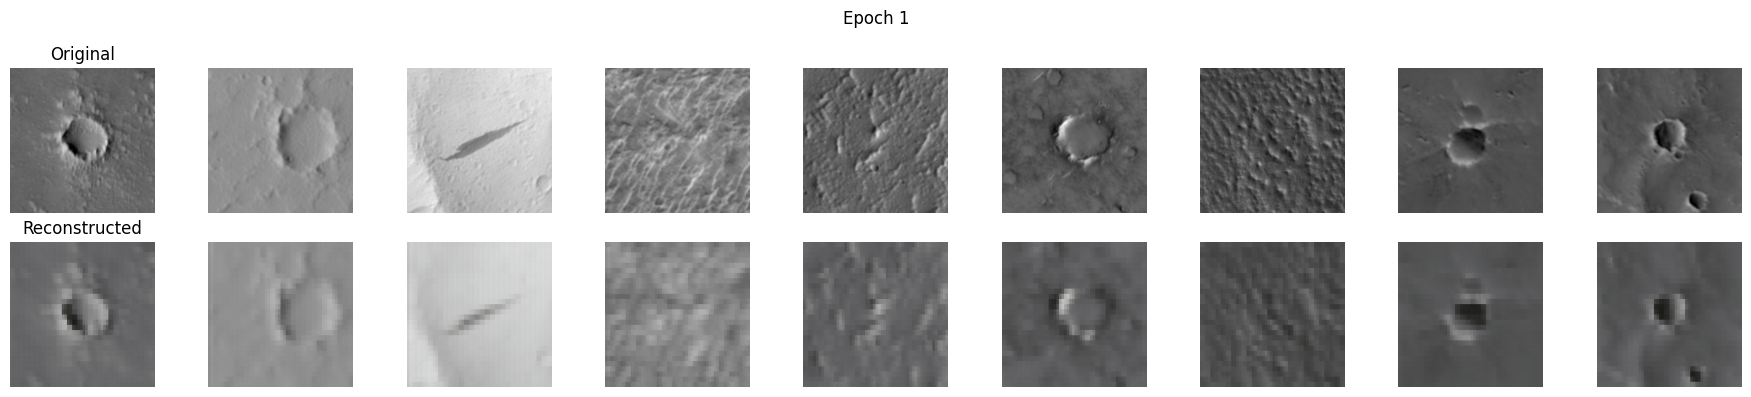

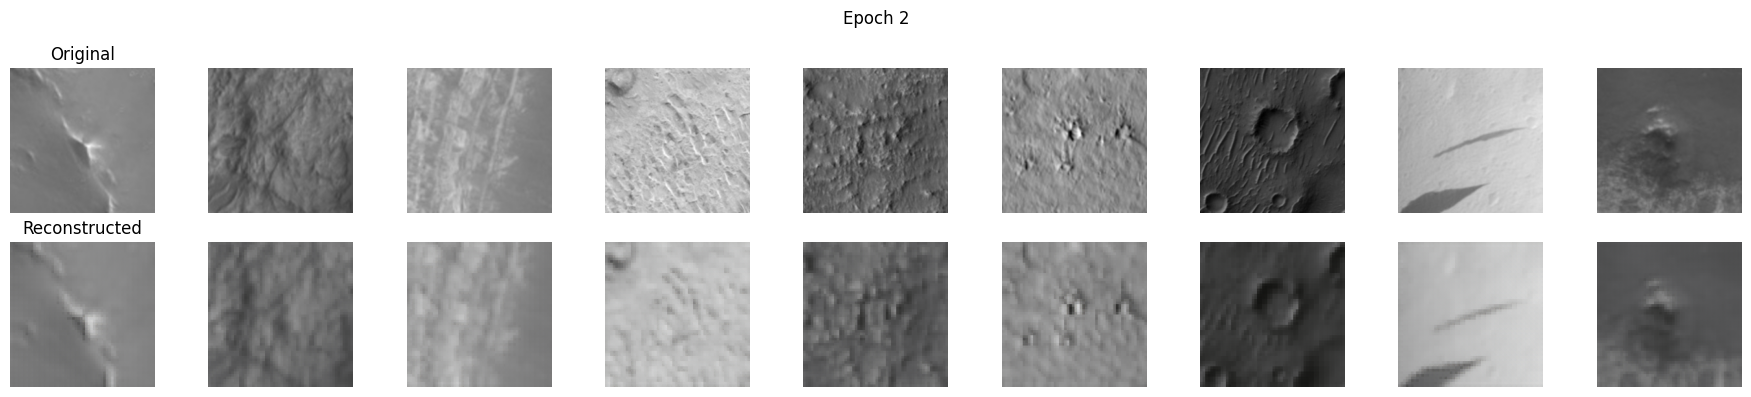

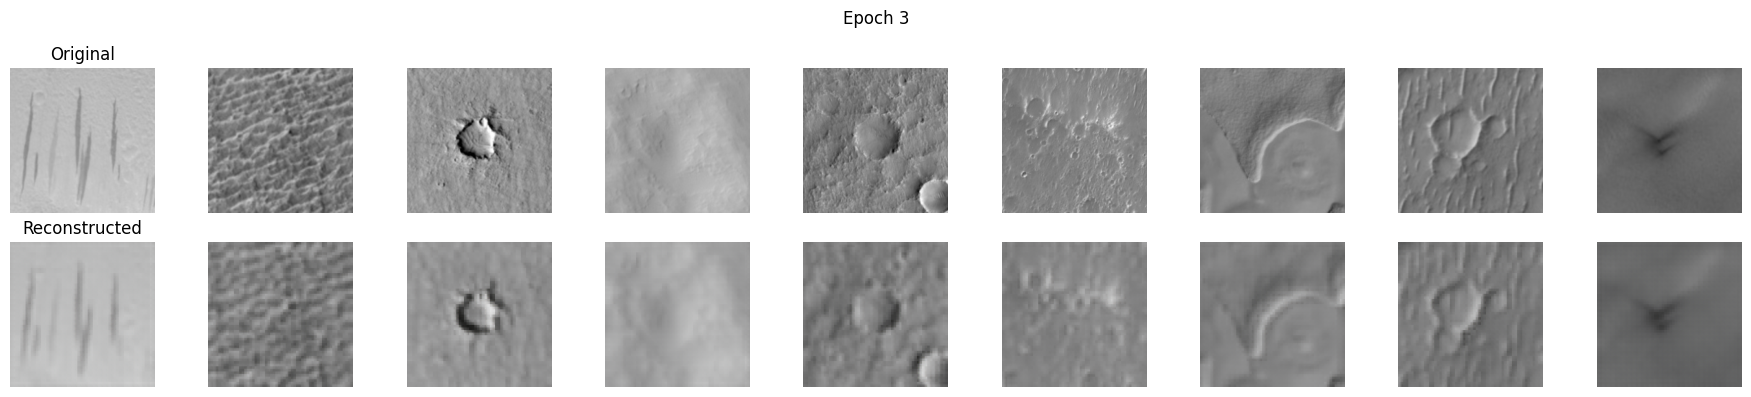

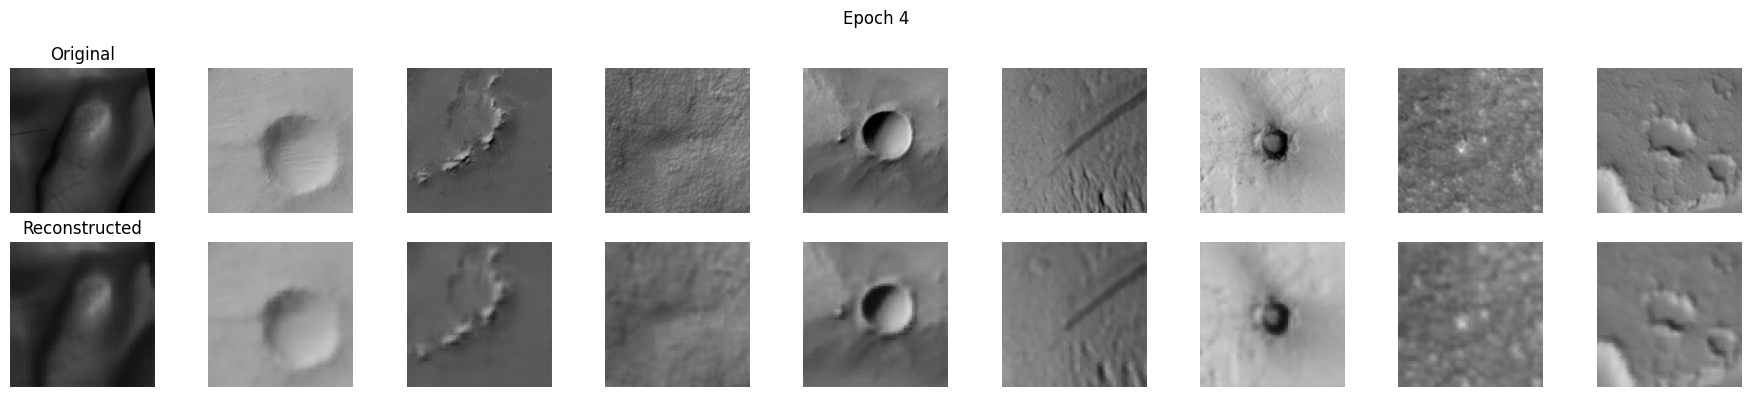

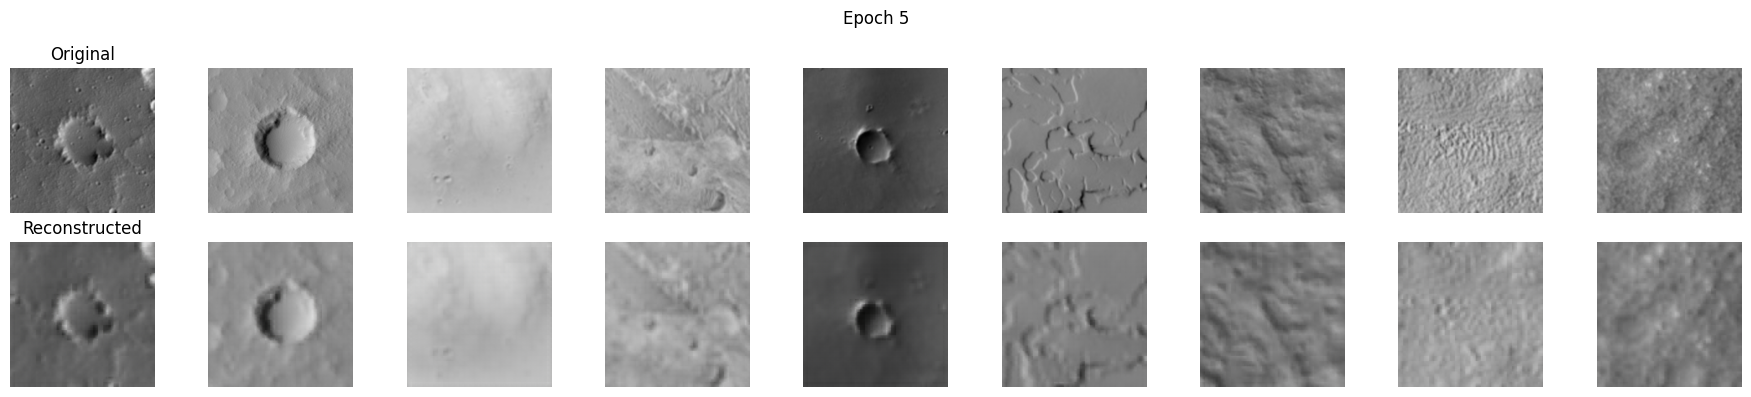

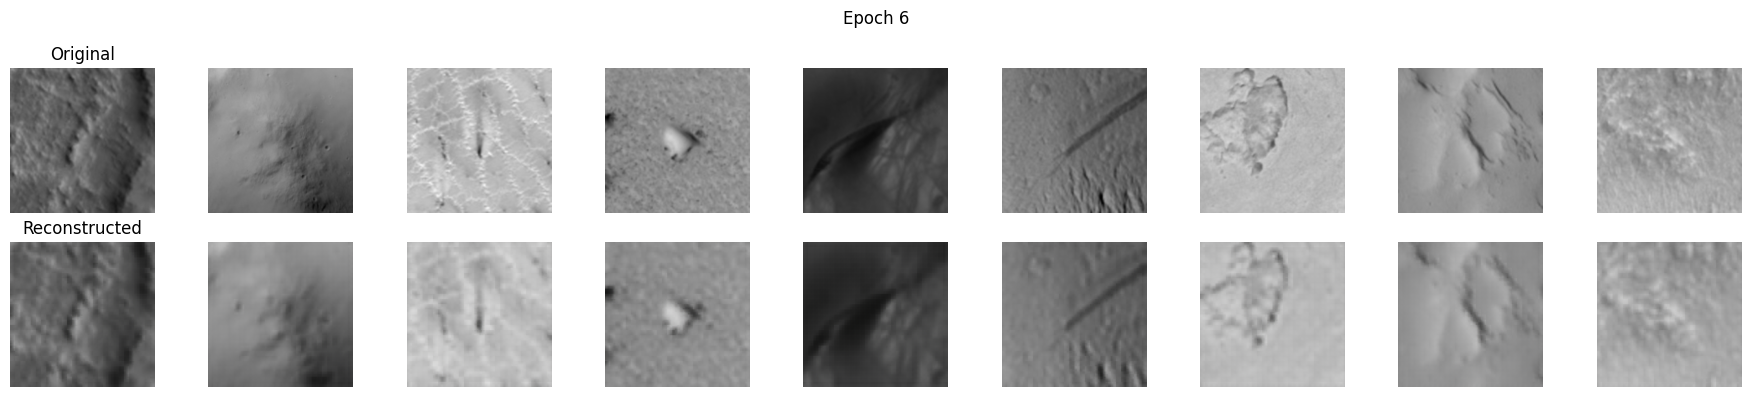

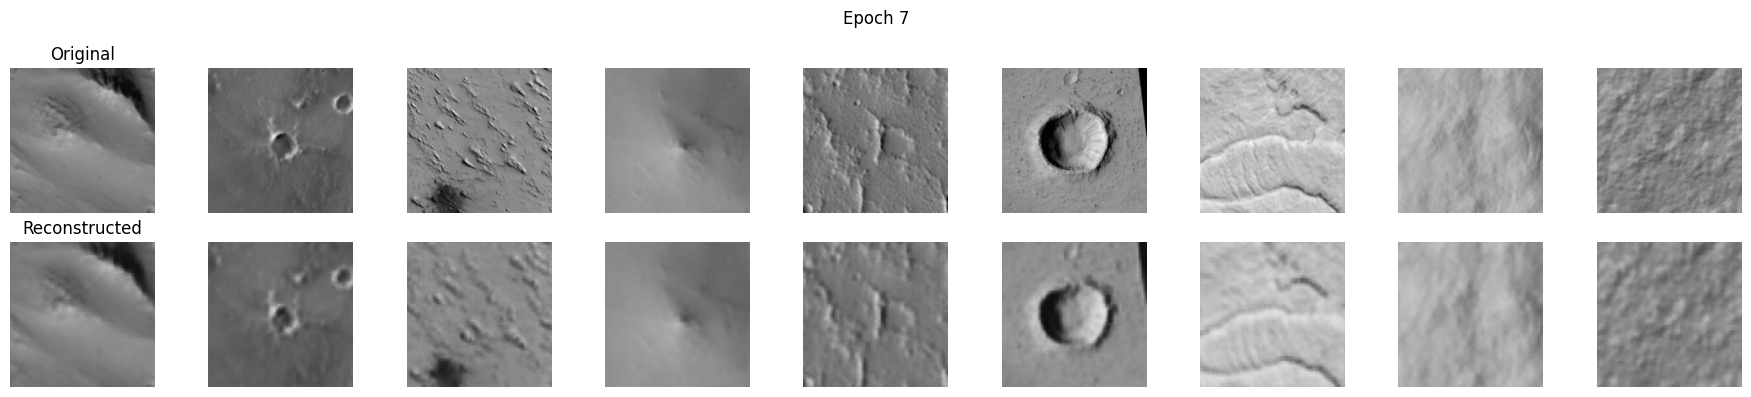

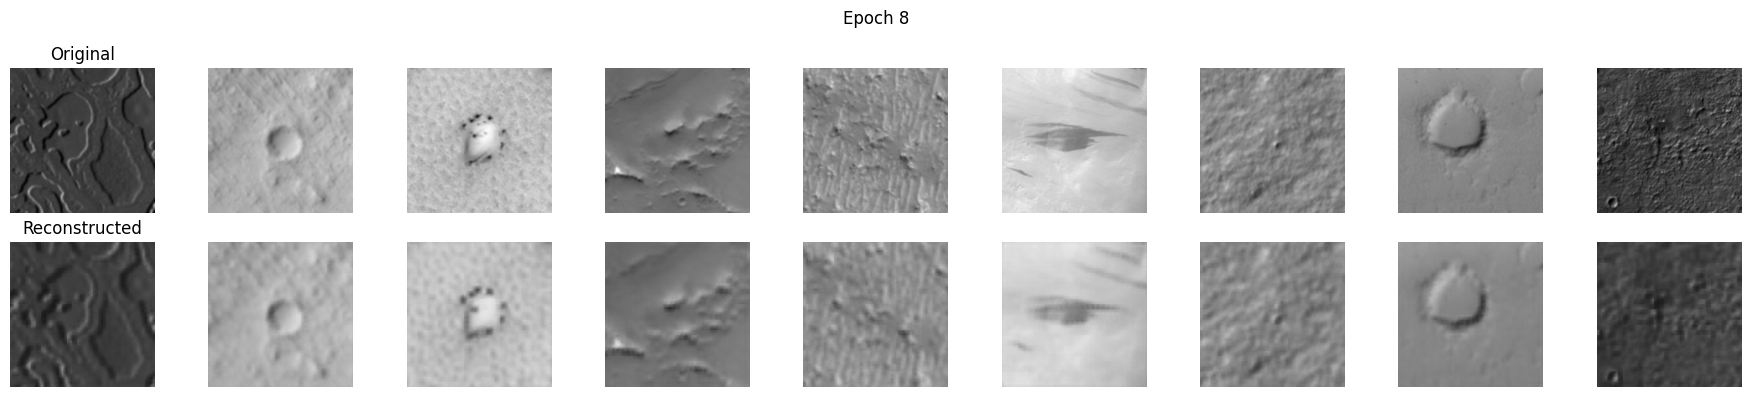

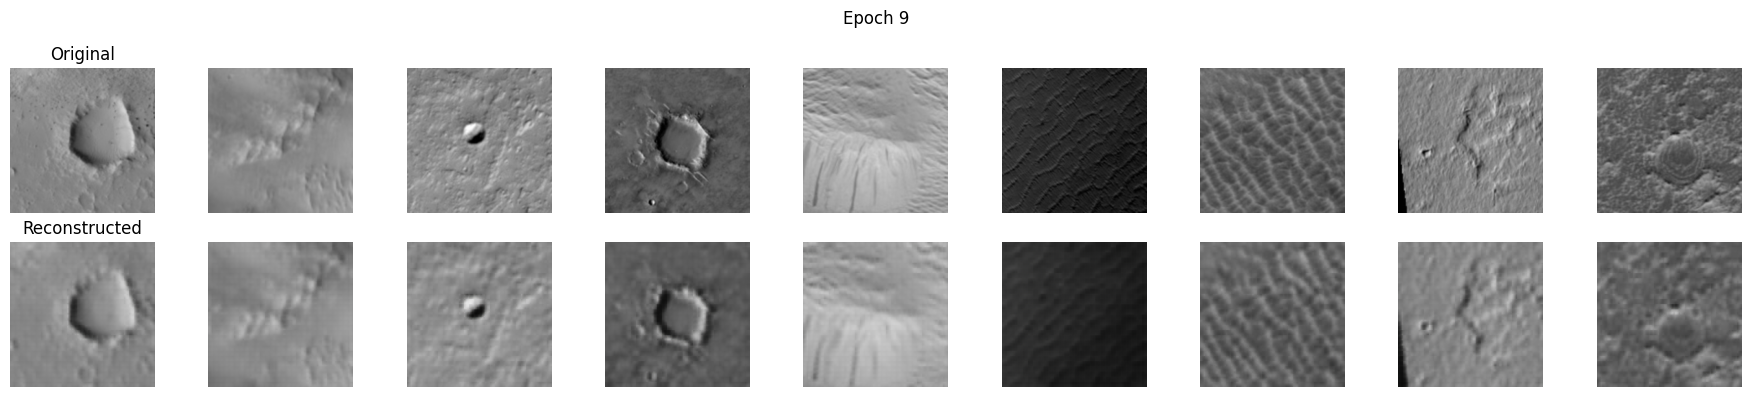

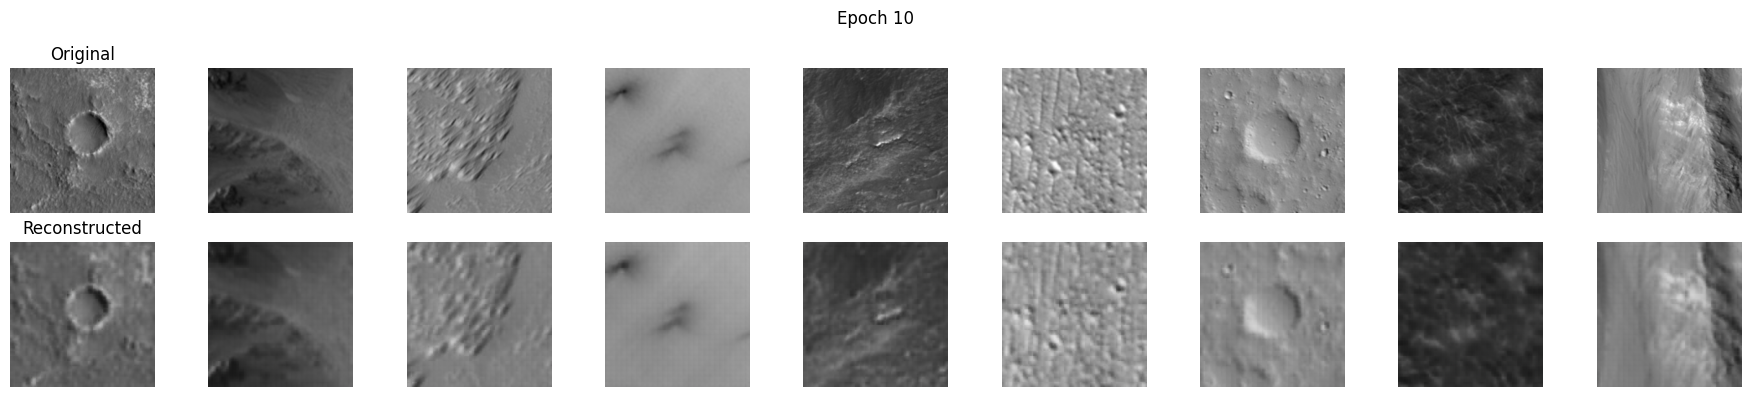

In [12]:
import matplotlib.pyplot as plt
for k in range(num_epochs):
    plt.figure(figsize=(18, 4))
    imgs = outputs[k][1].detach().cpu().numpy().transpose(0, 2, 3, 1)
    recon = outputs[k][2].detach().cpu().numpy().transpose(0, 2, 3, 1)
    for i, item in enumerate(imgs):
        if i >= 9:
            break
        plt.subplot(2, 9, i + 1)
        plt.imshow(item) # Display RGB image directly
        plt.axis('off')
        if i == 0:
            plt.title("Original")
    for i, item in enumerate(recon):
        if i >= 9:
            break
        plt.subplot(2, 9, 9 + i + 1)
        plt.imshow(item) # Display reconstructed RGB image
        plt.axis('off')
        if i == 0:
            plt.title("Reconstructed")
    plt.suptitle(f"Epoch {k + 1}")
    plt.tight_layout()
    plt.show()


In [14]:
import glob
import numpy as np
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve

TEST_NORMAL_DIR = 'dataset_split/dataset_split/test/normal'
TEST_ANOMALY_DIR = 'dataset_split/dataset_split/test/anomaly_real'
IMG_SIZE = 224  # match what you trained on (Cell 4 used 224x224)

class ScoringDataset(torch.utils.data.Dataset):
    def __init__(self, folder, img_size=IMG_SIZE):
        self.paths = sorted(glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png')))
        self.img_size = img_size
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        im = Image.open(self.paths[i]).convert('RGB').resize((self.img_size, self.img_size))
        arr = np.asarray(im, dtype=np.float32) / 255.0
        arr = arr.transpose(2, 0, 1)  # HWC -> CHW
        return torch.from_numpy(arr)

print("Test normal:", len(glob.glob(TEST_NORMAL_DIR + '/*.jpg')) + len(glob.glob(TEST_NORMAL_DIR + '/*.png')))
print("Test anomaly:", len(glob.glob(TEST_ANOMALY_DIR + '/*.jpg')) + len(glob.glob(TEST_ANOMALY_DIR + '/*.png')))

Test normal: 2098
Test anomaly: 5125


In [15]:
import torch.nn.functional as F

def patch_max_score(x, recon, patch=16):
    err = (recon - x) ** 2
    pooled = F.avg_pool2d(err, kernel_size=patch, stride=patch)
    return pooled.amax(dim=[1, 2, 3]).cpu().numpy()

def score_folder(folder):
    ds = ScoringDataset(folder)
    loader = torch.utils.data.DataLoader(ds, batch_size=64, shuffle=False)
    scores = []
    model.eval()
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            recon = model(x)
            scores.extend(patch_max_score(x, recon, patch=IMG_SIZE // 8).tolist())
    return np.array(scores), ds.paths

normal_scores, normal_paths = score_folder(TEST_NORMAL_DIR)
anomaly_scores, anomaly_paths = score_folder(TEST_ANOMALY_DIR)

print(f"normal: n={len(normal_scores)}, mean={normal_scores.mean():.5f}")
print(f"anomaly: n={len(anomaly_scores)}, mean={anomaly_scores.mean():.5f}")

normal: n=2098, mean=0.00300
anomaly: n=5125, mean=0.00772


### AUC + ROC curve


>>> AUTOENCODER AUC: 0.9163
>>> Threshold (95th pct of normal): 0.00823
>>> Flagged rate on normal: 0.050
>>> Flagged rate on anomaly: 0.334


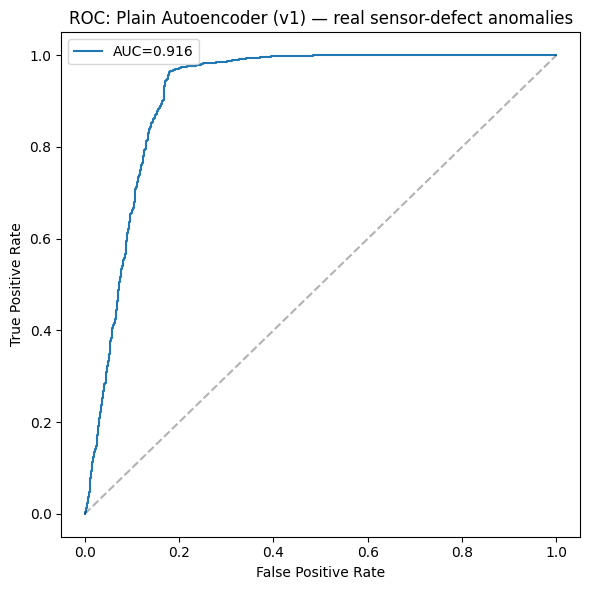

In [ ]:
y = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anomaly_scores))])
scores_all = np.concatenate([normal_scores, anomaly_scores])
overall_auc = roc_auc_score(y, scores_all)
threshold = np.percentile(normal_scores, 95)

print(f"\n>>> AUTOENCODER AUC: {overall_auc:.4f}")
print(f">>> Threshold (95th pct of normal): {threshold:.5f}")
print(f">>> Flagged rate on normal: {(normal_scores > threshold).mean():.3f}")
print(f">>> Flagged rate on anomaly: {(anomaly_scores > threshold).mean():.3f}")

fpr, tpr, _ = roc_curve(y, scores_all)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC={overall_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC: Plain Autoencoder (v1) — real sensor-defect anomalies')
plt.legend(); plt.tight_layout()
plt.savefig('fig_autoencoder_v1_roc.png', dpi=120)
plt.show()

### Result

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

y_pred = (scores_all > threshold).astype(int)   # convert scores -> 0/1 predictions using your existing threshold

precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
accuracy = accuracy_score(y, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print(f"\nConfusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Precision: 0.9421
Recall:    0.3337
F1 score:  0.4928
Accuracy:  0.5127

Confusion matrix: TN=1993, FP=105, FN=3415, TP=1710
